# Full simulation-backed DEXPI engineering assurance package

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/equinor/neqsim/blob/master/examples/notebooks/dexpi_engineering_full_processsystem.ipynb)

This executable example builds a gas-compression `ProcessSystem`, adds controlled piping, installed-relief, evidence, SIF, shutdown, dynamic ESD, blowdown/flare, materials and compressor-map inputs, and exports a governed DEXPI engineering package with registers, validation and SHA-256 integrity records.

The calculations support concept and FEED engineering. They remain `REVIEW_REQUIRED`: HAZOP/LOPA decisions, final SIL/SRS approval, vendor certification, detailed relief-header/stress/layout work and accountable engineering approval remain controlled project activities.

## 1. Load workspace NeqSim classes

In [1]:
import os
import subprocess
import sys
from pathlib import Path


def find_neqsim_project_root():
    env_root = os.environ.get("NEQSIM_PROJECT_ROOT")
    candidates = [Path(env_root).resolve()] if env_root else []
    cwd = Path.cwd().resolve()
    candidates.extend([cwd] + list(cwd.parents))
    for candidate in candidates:
        if (candidate / "pom.xml").exists() and (candidate / "devtools" / "neqsim_dev_setup.py").exists():
            return candidate
    return None


PROJECT_ROOT = find_neqsim_project_root()
if PROJECT_ROOT is None:
    # Colab/external fallback: clone and compile the current public source tree.
    PROJECT_ROOT = Path("/content/neqsim") if Path("/content").exists() else Path.cwd() / "neqsim-workspace"
    if not (PROJECT_ROOT / "pom.xml").exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/equinor/neqsim.git", str(PROJECT_ROOT)],
            check=True,
        )

sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes

needs_compile = not (PROJECT_ROOT / "target" / "classes").exists()
ns = neqsim_classes(
    neqsim_init(project_root=PROJECT_ROOT, recompile=needs_compile, verbose=False)
)
JClass = ns.JClass
print(f"NeqSim workspace loaded from {PROJECT_ROOT}")

All NeqSim classes imported OK
NeqSim workspace loaded from /workspace/scratch/0f75633c511c/neqsim


In [2]:
import json
import shutil
import xml.etree.ElementTree as ET
from pathlib import Path

import jpype
import matplotlib.pyplot as plt
import pandas as pd

SystemSrkEos = JClass("neqsim.thermo.system.SystemSrkEos")
ProcessSystem = JClass("neqsim.process.processmodel.ProcessSystem")
Stream = JClass("neqsim.process.equipment.stream.Stream")
Separator = JClass("neqsim.process.equipment.separator.Separator")
Compressor = JClass("neqsim.process.equipment.compressor.Compressor")
AdiabaticPipe = JClass("neqsim.process.equipment.pipeline.AdiabaticPipe")
ThrottlingValve = JClass("neqsim.process.equipment.valve.ThrottlingValve")
ESDValve = JClass("neqsim.process.equipment.valve.ESDValve")
DesignConditions = JClass("neqsim.process.mechanicaldesign.DesignConditions")
FailureAction = JClass("neqsim.process.mechanicaldesign.DesignConditions$FailureAction")
EngineeringBuilder = JClass("neqsim.process.engineering.NorsokOffshoreEngineeringBuilder")
EngineeringRunner = JClass("neqsim.process.engineering.SimulationEngineeringDesignRunner")
EngineeringExporter = JClass("neqsim.process.engineering.dexpi.DexpiEngineeringExporter")
LineDesignInput = JClass("neqsim.process.engineering.LineDesignInput")
ReliefScenarioBasis = JClass("neqsim.process.engineering.ReliefScenarioBasis")
SafetyFunctionDesign = JClass("neqsim.process.engineering.SafetyFunctionDesign")
SifSubsystem = JClass("neqsim.process.engineering.SafetyFunctionDesign$Subsystem")
SubsystemType = JClass("neqsim.process.engineering.SafetyFunctionDesign$SubsystemType")
ReliefDeviceDesignInput = JClass("neqsim.process.engineering.ReliefDeviceDesignInput")
EngineeringEvidenceRecord = JClass("neqsim.process.engineering.EngineeringEvidenceRecord")
ShutdownSequence = JClass("neqsim.process.engineering.ShutdownSequence")
ShutdownAction = JClass("neqsim.process.engineering.ShutdownSequence$Action")
BlockedOutletRelief = JClass("neqsim.process.safety.overpressure.BlockedOutletRelief")
ProtectedItem = JClass("neqsim.process.safety.overpressure.ProtectedItem")
OverpressureProtectionStudy = JClass("neqsim.process.safety.overpressure.OverpressureProtectionStudy")
ReliefScenario = JClass("neqsim.process.safety.overpressure.ReliefScenario")
ReliefCause = JClass("neqsim.process.safety.overpressure.ReliefCause")
ReliefPhase = JClass("neqsim.process.safety.overpressure.ReliefPhase")
BlowdownSource = JClass("neqsim.process.safety.depressurization.DynamicBlowdownFlareStudyDataSource$BlowdownSource")
BlowdownFlareDataSource = JClass("neqsim.process.safety.depressurization.DynamicBlowdownFlareStudyDataSource")
MaterialsReviewInput = JClass("neqsim.process.materials.MaterialsReviewInput")
ESDLogic = JClass("neqsim.process.logic.esd.ESDLogic")
TripValveAction = JClass("neqsim.process.logic.action.TripValveAction")
OperationalTagMap = JClass("neqsim.process.operations.OperationalTagMap")
OperationalTagBinding = JClass("neqsim.process.operations.OperationalTagBinding")
InstrumentTagRole = JClass("neqsim.process.measurementdevice.InstrumentTagRole")
EmergencyShutdownTestPlan = JClass("neqsim.process.safety.esd.EmergencyShutdownTestPlan")
EmergencyShutdownTestCriterion = JClass("neqsim.process.safety.esd.EmergencyShutdownTestCriterion")
EmergencyShutdownTestRunner = JClass("neqsim.process.safety.esd.EmergencyShutdownTestRunner")
Paths = JClass("java.nio.file.Paths")

OUTPUT_DIR = PROJECT_ROOT / "build" / "notebook-output" / "dexpi-engineering-processsystem"
if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True)
print(f"Outputs: {OUTPUT_DIR}")

Outputs: /workspace/scratch/0f75633c511c/neqsim/build/notebook-output/dexpi-engineering-processsystem


## 2. Build and run the process model

In [3]:
fluid = SystemSrkEos(303.15, 50.0)
for component, amount in [("methane", 0.90), ("ethane", 0.07), ("propane", 0.02), ("CO2", 0.01)]:
    fluid.addComponent(component, amount)
fluid.setMixingRule("classic")

feed = Stream("20-FEED-001", fluid)
feed.setFlowRate(0.50, "MSm3/day")

separator = Separator("20-VG-001", feed)
separator.setDesignConditions(
    DesignConditions()
    .setDesignPressure(70.0)
    .setReliefSetPressure(68.0)
    .setMaxDesignTemperature(80.0)
    .setMinDesignTemperature(-46.0)
    .setConstructionMaterial("Carbon steel")
    .setCorrosionAllowance(3.0)
)

compressor = Compressor("20-KA-001", separator.getGasOutStream())
compressor.setOutletPressure(100.0, "bara")
compressor.setDesignConditions(
    DesignConditions().setDesignPressure(120.0).setMaxDesignTemperature(150.0)
)

export_pipe = AdiabaticPipe("20-PL-001", compressor.getOutletStream())
export_pipe.setLength(1000.0)
export_pipe.setDiameter(0.30)
export_pipe.setWallThickness(0.012)
export_pipe.setPipeWallRoughness(5.0e-6)
export_pipe.setDesignPressure(120.0, "bara")
export_pipe.setDesignTemperature(120.0)
export_pipe.setMaterialGrade("A106-B")
export_pipe.setDesignConditions(
    DesignConditions()
    .setDesignPressure(120.0)
    .setMaxDesignTemperature(120.0)
    .setMinDesignTemperature(-46.0)
    .setConstructionMaterial("A106-B carbon steel")
    .setCorrosionAllowance(3.0)
)

export_valve = ThrottlingValve("20-PV-001", export_pipe.getOutletStream())
export_valve.setOutletPressure(95.0)
export_valve.setDesignConditions(
    DesignConditions()
    .setDesignPressure(120.0)
    .setMaxDesignTemperature(120.0)
    .setFailureAction(FailureAction.FAIL_CLOSED)
)

esd_valve = ESDValve("20-ESDV-001", export_valve.getOutletStream())
esd_valve.setCv(500.0)
esd_valve.setStrokeTime(6.0)
esd_valve.energize()
esd_valve.setPercentValveOpening(100.0)
esd_valve.setDesignConditions(
    DesignConditions().setDesignPressure(120.0).setMaxDesignTemperature(120.0)
    .setFailureAction(FailureAction.FAIL_CLOSED)
)

process = ProcessSystem()
process.setName("Gas compression and export")
for unit in [feed, separator, compressor, export_pipe, export_valve, esd_valve]:
    process.add(unit)
process.run()

# A compact design compressor map; a project may replace this with vendor data.
def jdouble1(values):
    return jpype.JArray(jpype.JDouble)(values)


def jdouble2(rows):
    return jpype.JArray(jpype.JDouble, 2)(
        [jpype.JArray(jpype.JDouble)(row) for row in rows]
    )


compressor.getCompressorChart().setCurves(
    jdouble1([19.0, 303.15, 50.0, 0.90]),
    jdouble1([8000.0, 10000.0]),
    jdouble2([[4000.0, 6000.0, 8000.0], [5000.0, 7500.0, 10000.0]]),
    jdouble2([[55.0, 50.0, 42.0], [85.0, 78.0, 65.0]]),
    jdouble2([[70.0, 78.0, 72.0], [71.0, 80.0, 73.0]]),
)
compressor.getCompressorChart().setUseCompressorChart(True)
compressor.getAntiSurge().setActive(True)

print(f"Converged process with export pressure {export_valve.getOutletStream().getPressure('bara'):.2f} bara")

Converged process with export pressure 95.00 bara


## 3. Add controlled engineering inputs and safety studies

In [4]:
project = (
    EngineeringBuilder.from_("Full DEXPI engineering demonstration", process)
    .registerProposedInstruments(True)
    .build()
)

# Controlled line-list row: simulation geometry is complemented by piping-class evidence.
project.addLineDesignInput(
    LineDesignInput("20-PL-001-A", "20-PL-001")
    .setNominalPipeSize("12")
    .setSchedule("STD")
    .setMaterialGrade("A106-B")
    .setPipingClass("HC-600")
    .setInsulationType("Mineral wool")
    .setOuterDiameter(323.9, "mm")
    .setNominalWallThickness(12.0, "mm")
    .setCorrosionAllowance(3.0, "mm")
    .setDesignPressureBara(120.0)
    .setDesignTemperatureC(120.0)
    .setEquivalentFittingsLengthM(25.0)
    .setProposedSupportSpacingM(5.0)
    .addEvidenceReference("LINE-LIST-20-REV-A (demonstration)")
)

# Explicit API 521 blocked-outlet and fire scenarios with a controlled coverage basis.
protected_separator = (
    ProtectedItem("20-VG-001", 70.0)
    .setReliefSetPressureBara(68.0)
    .setDesignTemperatureC(80.0)
    .setBackPressureBara(1.5)
)
blocked_outlet = (
    BlockedOutletRelief()
    .setName("Maximum credible blocked outlet")
    .setInflowRateKgPerS(feed.getFlowRate("kg/sec"))
    .setReliefPressureBara(68.0)
    .setReliefTemperatureC(30.0)
    .setFluid(feed.getFluid())
    .calculate()
)
fire_case = (
    ReliefScenario.Builder("External pool-fire screening", ReliefCause.FIRE)
    .phase(ReliefPhase.VAPOUR)
    .reliefRateKgPerS(2.5)
    .reliefTemperatureK(350.0)
    .molarMassKgPerMol(0.020)
    .compressibility(0.95)
    .specificHeatRatio(1.25)
    .addAssumption("Reviewed wetted-area fire load is required for project use")
    .build()
)
project.addOverpressureStudy(
    OverpressureProtectionStudy(protected_separator)
    .addScenario(blocked_outlet)
    .addScenario(fire_case)
)
project.addReliefScenarioBasis(
    ReliefScenarioBasis("20-VG-001")
    .require(ReliefCause.BLOCKED_OUTLET)
    .require(ReliefCause.FIRE)
    .setHazardReviewReference("HAZOP-20-001 (demonstration)")
    .addEvidenceReference("RELIEF-REGISTER-20-REV-A (demonstration)")
)
project.addReliefDeviceDesignInput(
    ReliefDeviceDesignInput("20-PSV-001", "20-VG-001")
    .setSelectedOrificeAreaIn2(10.0)
    .setInletPiping(0.10, 2.0, 2.0)
    .setOutletPiping(0.20, 20.0, 5.0)
    .setConcurrencyGroup("FIRE-ZONE-A")
    .setFireZone("A")
    .setTwoPhaseMethod("API_520_OMEGA_WHEN_APPLICABLE")
    .setEvidenceReference("PSV-DATASHEET-20-001-REV-A")
)

# The SIL target is imported from LOPA; NeqSim calculates transparent PFDavg screening.
pressure_sif_requirement = "20-KA-001-DISCHARGE-P-HH"
for requirement in project.getRequirements():
    if str(requirement.getId()) == pressure_sif_requirement:
        requirement.setSilTarget("SIL 2", "LOPA-20-001 (demonstration)")

project.addSafetyFunctionDesign(
    SafetyFunctionDesign("SIF-20-001", pressure_sif_requirement, 2)
    .setLopaReference("LOPA-20-001 (demonstration)")
    .setSrsReference("SRS-20-001 (demonstration)")
    .setSafeState("Compressor stopped and isolated")
    .addSubsystem(
        SifSubsystem("Discharge pressure transmitters", SubsystemType.SENSOR, 2, 3, 1.0e-6, 0.60, 8760.0, 8.0, 0.05)
        .setProofTestCoverage(0.95).setMissionTimeHours(87600.0)
        .setCommonCauseGroup("PT-20-001").setArchitecturalConstraints(2, 1)
        .setCertifiedDataReference("SIL-CERT-PT-001")
    )
    .addSubsystem(
        SifSubsystem("Safety logic solver", SubsystemType.LOGIC_SOLVER, 1, 1, 1.0e-7, 0.90, 8760.0, 8.0, 0.0)
        .setProofTestCoverage(0.99).setMissionTimeHours(87600.0)
        .setArchitecturalConstraints(3, 0).setCertifiedDataReference("SIL-CERT-LS-001")
    )
    .addSubsystem(
        SifSubsystem("Trip and isolation", SubsystemType.FINAL_ELEMENT, 1, 1, 2.0e-6, 0.50, 8760.0, 8.0, 0.0)
        .setProofTestCoverage(0.90).setPartialStrokeTesting(2160.0, 0.60)
        .setMissionTimeHours(87600.0).setArchitecturalConstraints(2, 0)
        .setCertifiedDataReference("SIL-CERT-FE-001")
    )
)

project.addShutdownSequence(
    ShutdownSequence("ESD-20-001", "High-high compressor discharge pressure")
    .setProtectedEquipmentTag("20-KA-001")
    .setSafeState("Compressor stopped and isolated")
    .setHazopReference("HAZOP-20-001 (demonstration)")
    .setSrsReference("SRS-20-001 (demonstration)")
    .setResponseTimeBudgetSeconds(12.0)
    .setResetAndRestartDefined(True)
    .addRequirementId(pressure_sif_requirement)
    .addAction(ShutdownAction("20-KA-001", "Trip compressor driver", "STOPPED", 0.5, 1.0))
    .addAction(ShutdownAction("ESDV-20-001", "Close discharge isolation", "CLOSED", 1.0, 6.0))
)

# Readiness-gated transient blowdown, PSV and flare load study.
blowdown_source = (
    BlowdownSource.builder("BD-20-VG-001", separator.getGasOutStream().getFluid())
    .equipmentTag("20-VG-001")
    .vesselVolumeM3(20.0)
    .orificeDiameterM(0.025)
    .dischargeCoefficient(0.72)
    .backPressureBara(1.5)
    .stopPressureBara(7.0)
    .api521FireCase(25.0, True, True)
    .wallModel(5000.0, 45.0, 470.0, 50.0)
    .psvBasis(68.0, 0.21, True, False)
    .build()
)
blowdown_flare = (
    BlowdownFlareDataSource.builder("BD-FLARE-20-001")
    .addSource(blowdown_source)
    .flareHeader(0.40, 1.5, 288.15, 0.020, 1.30)
    .maxAllowableHeaderMach(0.70)
    .flareGeometry(0.80, 50.0, 0.20)
    .flareDesignCapacity(100.0e6, 50.0, 2500.0)
    .sourceDiagramsReviewed(True)
    .pidTopologyVerified(True)
    .lineEquipmentListsReviewed(True)
    .pipingSpecificationRowsReviewed(True)
    .vesselInventoryReviewed(True)
    .valveSizingBasisReviewed(True)
    .psvBasisReviewed(True)
    .flareSystemBasisReviewed(True)
    .fireCaseReviewed(True)
    .standardsReviewed(True)
    .humanReviewRequired(True)
    .build()
)
project.addBlowdownFlareStudy(blowdown_flare)

# Revision-controlled evidence is indexed and linked to equipment/requirements.
project.addEvidenceRecord(
    EngineeringEvidenceRecord("HAZOP-20-001", "HAZOP", "A")
    .setTitle("Compression-train HAZOP demonstration")
    .setSourceOrganization("Project technical safety")
    .linkEquipment("20-VG-001").linkEquipment("20-KA-001")
    .linkRequirement(pressure_sif_requirement)
)
project.addEvidenceRecord(
    EngineeringEvidenceRecord("LINE-LIST-20", "LINE_LIST", "A")
    .setTitle("Compression line-list demonstration")
    .setSourceOrganization("Project piping").linkEquipment("20-PL-001")
)
project.addEvidenceRecord(
    EngineeringEvidenceRecord("VALVE-DATA-20", "VENDOR_DATA", "A")
    .setTitle("Shutdown and control valve demonstration data")
    .setSourceOrganization("Demonstration vendor")
    .linkEquipment("20-PV-001").linkEquipment("20-ESDV-001")
)

# Dynamic ESD evidence is run on a focused transient test fixture. The full design
# model contains steady-state pipe models that are intentionally not transient solvers.
esd_test_feed = Stream("20-ESD-TEST-FEED", fluid.clone())
esd_test_feed.setFlowRate(0.50, "MSm3/day")
esd_test_valve = ESDValve("20-ESDV-001-TEST", esd_test_feed)
esd_test_valve.setCv(500.0)
esd_test_valve.setStrokeTime(6.0)
esd_test_process = ProcessSystem()
esd_test_process.setName("20-ESDV-001 dynamic test fixture")
esd_test_process.add(esd_test_feed)
esd_test_process.add(esd_test_valve)
esd_test_process.run()

esd_logic = ESDLogic("ESD-20-001")
esd_logic.addAction(TripValveAction(esd_test_valve), 0.0)
tag_map = OperationalTagMap().addBinding(
    OperationalTagBinding.builder("esdv_opening")
    .historianTag("DEMO-20-ESDV-001-POS")
    .pidReference("P&ID-DEMO/20-ESDV-001")
    .automationAddress("20-ESDV-001-TEST.percentValveOpening")
    .unit("%").role(InstrumentTagRole.BENCHMARK).build()
)
esd_plan = (
    EmergencyShutdownTestPlan.builder("ESD-20-001 dynamic closure")
    .duration(8.0).timeStep(1.0).tagMap(tag_map)
    .enableLogic("ESD-20-001").triggerLogic("ESD-20-001")
    .criterion(EmergencyShutdownTestCriterion.finalAtMost("ESDV-CLOSED", "esdv_opening", 5.0, "%"))
    .criterion(EmergencyShutdownTestCriterion.logicCompleted("ESD-LOGIC-COMPLETE", "ESD-20-001"))
    .criterion(EmergencyShutdownTestCriterion.noSimulationErrors("ESD-NO-SIM-ERRORS"))
    .standardReference("IEC 61511 functional testing; NORSOK S-001 emergency shutdown")
    .evidenceReference("Cause-and-effect demonstration row ESD-20-001").build()
)
esd_result = EmergencyShutdownTestRunner.run(esd_test_process, esd_plan, esd_logic)
project.addShutdownVerificationResult("ESD-20-001", esd_result)

project.setMaterialsReviewInput(
    MaterialsReviewInput().setProjectName("Full DEXPI engineering demonstration").setDesignLifeYears(25.0)
)

print(f"Generated {len(project.getRequirements())} governed engineering requirements")

Generated 20 governed engineering requirements


## 4. Calculate and export the complete exchange package

In [5]:
calculation_report = EngineeringRunner.run(project)
calculation_data = json.loads(str(calculation_report.toJson()))

files = EngineeringExporter.export(project, Paths.get(str(OUTPUT_DIR)))
calculations_path = Path(str(files.getCalculationsFile().toString()))
manifest_path = Path(str(files.getManifestFile().toString()))
dexpi20_path = Path(str(files.getDexpi20File().toString()))
proteus_path = Path(str(files.getDexpiFile().toString()))
pydexpi_path = Path(str(files.getPyDexpiFile().toString()))
interoperability_path = Path(str(files.getInteroperabilityReportFile().toString()))
cause_effect_path = Path(str(files.getCauseAndEffectFile().toString()))
validation_path = Path(str(files.getValidationFile().toString()))
package_manifest_path = Path(str(files.getPackageManifestFile().toString()))

# Read the exported copy to demonstrate the on-disk exchange package.
calculation_data = json.loads(calculations_path.read_text())
manifest_data = json.loads(manifest_path.read_text())
cause_effect_data = json.loads(cause_effect_path.read_text())

summary = pd.DataFrame([
    {"Deliverable": "Native DEXPI 2.0 XML", "Path": dexpi20_path.name, "Exists": dexpi20_path.exists()},
    {"Deliverable": "Proteus graphical P&ID", "Path": proteus_path.name, "Exists": proteus_path.exists()},
    {"Deliverable": "pyDEXPI compatibility XML", "Path": pydexpi_path.name, "Exists": pydexpi_path.exists()},
    {"Deliverable": "Interoperability report", "Path": interoperability_path.name, "Exists": interoperability_path.exists()},
    {"Deliverable": "Engineering manifest", "Path": manifest_path.name, "Exists": manifest_path.exists()},
    {"Deliverable": "Engineering calculations", "Path": calculations_path.name, "Exists": calculations_path.exists()},
    {"Deliverable": "Cause and effect", "Path": cause_effect_path.name, "Exists": cause_effect_path.exists()},
    {"Deliverable": "DEXPI validation", "Path": validation_path.name, "Exists": validation_path.exists()},
    {"Deliverable": "SHA-256 package manifest", "Path": package_manifest_path.name, "Exists": package_manifest_path.exists()},
    {"Deliverable": "Engineering registers", "Path": "registers/", "Exists": (OUTPUT_DIR / "registers" / "instrument-index.csv").exists()},
    {"Deliverable": "Compressor map", "Path": "datasets/20-KA-001-compressor-map.json", "Exists": (OUTPUT_DIR / "datasets" / "20-KA-001-compressor-map.json").exists()},
])
display(summary)
print("Document status:", calculation_data["documentStatus"])
print("Fitness for construction:", calculation_data["governance"]["fitnessForConstruction"])

Document status: CALCULATED_AND_PROPOSED_REVIEW_REQUIRED
Fitness for construction: False


,Deliverable,Path,Exists
0,Native DEXPI 2.0 XML,plant.dexpi.xml,True
1,Proteus graphical P&ID,plant-proteus.xml,True
2,pyDEXPI compatibility XML,plant-pydexpi.xml,True
3,Interoperability report,interoperability-report.json,True
4,Engineering manifest,engineering-manifest.json,True
5,Engineering calculations,engineering-calculations.json,True
6,Cause and effect,cause-and-effect.json,True
7,DEXPI validation,dexpi-validation.json,True
8,SHA-256 package manifest,package-manifest.json,True
9,Engineering registers,registers/,True


## 5. Inspect calculated equipment and safety results

In [6]:
equipment_rows = []
for item in calculation_data["equipmentMechanicalDesign"]:
    op = item.get("simulationOperatingPoint", {})
    result = item.get("result", {})
    equipment_rows.append({
        "Tag": item["equipmentTag"],
        "Class": item["equipmentClass"].split(".")[-1],
        "Pressure (bara)": op.get("pressureBara"),
        "Temperature (°C)": op.get("temperatureC"),
        "Status": item["status"],
        "P-002 acceptable": item.get("norsokP002LineSizingValidation", {}).get("acceptable"),
        "Calculated wall (mm)": result.get("dimensions", {}).get("wallThickness"),
    })
display(pd.DataFrame(equipment_rows))

psv = calculation_data["overpressureAndPsvSizing"][0]
psv_result = psv["result"]
flare = calculation_data["dynamicBlowdownAndFlareSizing"][0]["result"]["flareLoad"]
blowdown = calculation_data["dynamicBlowdownAndFlareSizing"][0]["result"]["sourceResults"]["BD-20-VG-001"]
materials = calculation_data["materialsAndCorrosionScreening"]
sif = calculation_data["silAndVotingVerification"][0]
shutdown = calculation_data["shutdownSequenceVerification"][0]
installed_relief = calculation_data["installedReliefDeviceVerification"][0]

key_results = pd.DataFrame([
    {"Result": "PSV required area", "Value": psv_result["requiredAreaIn2"], "Unit": "in²", "Status": psv["status"]},
    {"Result": "PSV selected orifice", "Value": psv_result["recommendedOrifice"], "Unit": "API letter", "Status": "REVIEW_REQUIRED"},
    {"Result": "Installed PSV screen", "Value": installed_relief.get("estimatedInletLossPercentSetPressure"), "Unit": "% set P", "Status": installed_relief["status"]},
    {"Result": "Blowdown peak flow", "Value": blowdown["peakMassFlowKgPerS"], "Unit": "kg/s", "Status": "CALCULATED"},
    {"Result": "Flare peak heat duty", "Value": flare["peakHeatDutyMW"], "Unit": "MW", "Status": "CALCULATED"},
    {"Result": "SIF PFDavg", "Value": sif["pfdAverage"], "Unit": "-", "Status": sif["status"]},
    {"Result": "SIF achieved / target SIL", "Value": f'{sif["achievedSil"]} / {sif["targetSil"]}', "Unit": "SIL", "Status": "TARGET_MET" if sif["targetMet"] else "TARGET_NOT_MET"},
    {"Result": "Dynamic ESD verdict", "Value": shutdown["dynamicValidationStatus"], "Unit": "-", "Status": "SIMULATED"},
    {"Result": "Shutdown response / budget", "Value": f'{shutdown["totalResponseTimeSeconds"]} / {shutdown["responseTimeBudgetSeconds"]}', "Unit": "s", "Status": shutdown["status"]},
    {"Result": "Materials verdict", "Value": materials["overallVerdict"], "Unit": "-", "Status": "SCREENING"},
])
display(key_results)

,Tag,Class,Pressure (bara),Temperature (°C),Status,P-002 acceptable,Calculated wall (mm)
0,20-VG-001,Separator,50.0,30.000000,CALCULATED_SCREENING_REVIEW_REQUIRED,None,None
1,20-KA-001,Compressor,100.0,83.559426,CALCULATED_SCREENING_REVIEW_REQUIRED,None,None
2,20-PL-001,AdiabaticPipe,NaN,NaN,CALCULATED_SCREENING_REVIEW_REQUIRED,True,None
3,20-PV-001,ThrottlingValve,95.0,82.282909,CALCULATED_SCREENING_REVIEW_REQUIRED,None,None
4,20-ESDV-001,ESDValve,95.0,82.282909,CALCULATED_SCREENING_REVIEW_REQUIRED,None,None


,Result,Value,Unit,Status
0,PSV required area,0.477281,in²,CALCULATED_PSV_SIZE_REVIEW_REQUIRED
1,PSV selected orifice,G,API letter,REVIEW_REQUIRED
2,Installed PSV screen,0.099307,% set P,INSTALLED_RELIEF_SCREEN_ACCEPTED_REVIEW_REQUIRED
3,Blowdown peak flow,3.44856,kg/s,CALCULATED
4,Flare peak heat duty,176.3219,MW,CALCULATED
5,SIF PFDavg,0.004178,-,CALCULATED_PFD_AND_ARCHITECTURE_REVIEW_REQUIRED
6,SIF achieved / target SIL,2 / 2,SIL,TARGET_MET
7,Dynamic ESD verdict,PASS,-,SIMULATED
8,Shutdown response / budget,7.0 / 12.0,s,SEQUENCE_COMPLETE_REVIEW_REQUIRED
9,Materials verdict,PASS,-,SCREENING


## 6. Pressure design envelope

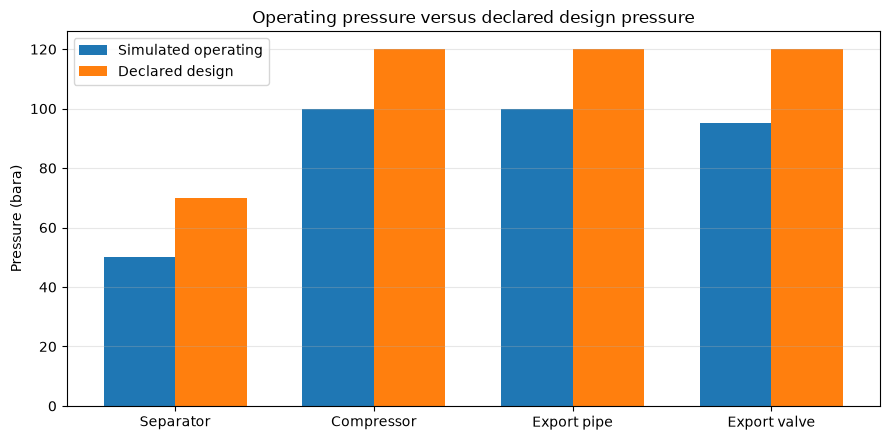

In [7]:
tags = ["Separator", "Compressor", "Export pipe", "Export valve"]
operating = [separator.getGasOutStream().getPressure("bara"), compressor.getOutletStream().getPressure("bara"), export_pipe.getOutletStream().getPressure("bara"), export_valve.getOutletStream().getPressure("bara")]
design = [70.0, 120.0, 120.0, 120.0]

fig, ax = plt.subplots(figsize=(9, 4.5))
x = range(len(tags))
ax.bar([i - 0.18 for i in x], operating, width=0.36, label="Simulated operating")
ax.bar([i + 0.18 for i in x], design, width=0.36, label="Declared design")
ax.set_xticks(list(x), tags)
ax.set_ylabel("Pressure (bara)")
ax.set_title("Operating pressure versus declared design pressure")
ax.grid(axis="y", alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "operating_vs_design_pressure.png", dpi=150, bbox_inches="tight")
plt.show()

**Discussion.** The declared pressure envelope is above the simulated normal operating point for every item. The gap is not itself an approval margin: instrument uncertainty, blocked-in settle-out, surge, relief accumulation and vendor limits can govern. Confirm every operating and accidental case before freezing data-sheet pressures.

## 7. Dynamic blowdown and flare load

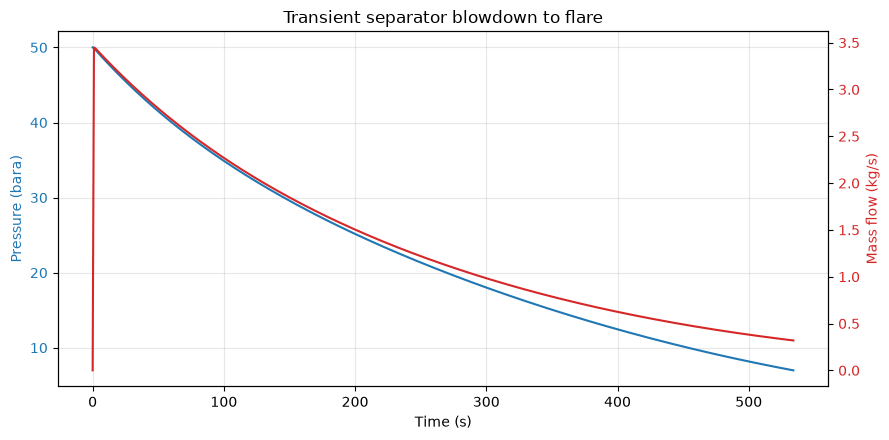

In [8]:
dynamic = calculation_data["dynamicBlowdownAndFlareSizing"][0]["result"]
profile = dynamic["sourceResults"]["BD-20-VG-001"]["profile"]
fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(profile["timeS"], profile["pressureBara"], color="tab:blue", label="Vessel pressure")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Pressure (bara)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.grid(alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(profile["timeS"], profile["massFlowKgPerS"], color="tab:red", label="Blowdown flow")
ax2.set_ylabel("Mass flow (kg/s)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax1.set_title("Transient separator blowdown to flare")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "blowdown_profile.png", dpi=150, bbox_inches="tight")
plt.show()

**Discussion.** Pressure and discharge rate fall nonlinearly as vessel inventory expands and cools. The peak flare load occurs early, while minimum fluid/wall temperature and time-to-pressure targets govern BDV and materials checks. Replace demonstration volume, fire, wall and header inputs with reviewed project evidence.

## 8. Evidence readiness by engineering topic

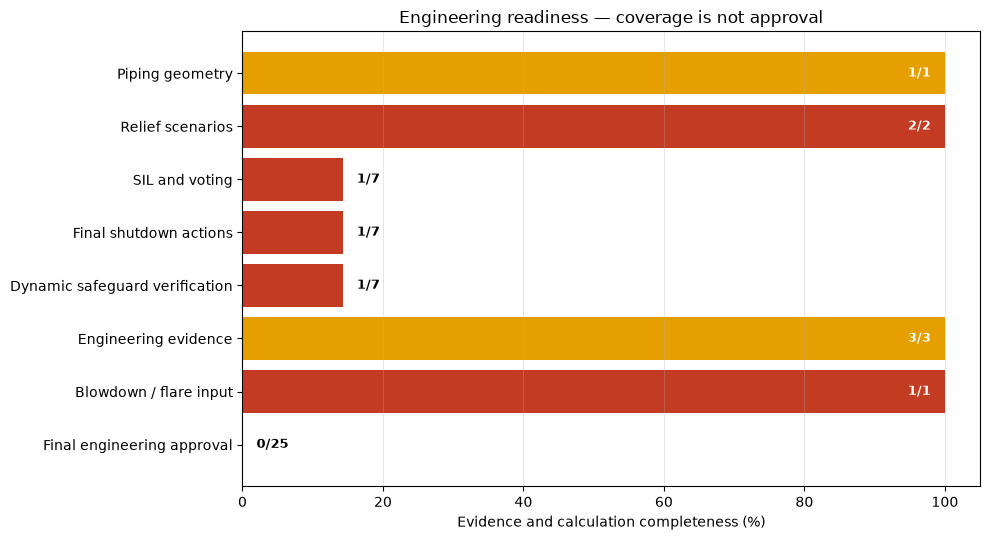

,Label,completenessPercent,missingInputCount,severity,responsibleDiscipline,approvalState
0,Piping geometry,100.000000,0,HIGH,Piping / process,REVIEW_REQUIRED
1,Relief scenarios,100.000000,0,CRITICAL,Process safety,REVIEW_REQUIRED
2,SIL and voting,14.285714,6,CRITICAL,Functional safety,REVIEW_REQUIRED
3,Final shutdown actions,14.285714,6,CRITICAL,Process / automation / technical safety,REVIEW_REQUIRED
4,Dynamic safeguard verification,14.285714,6,CRITICAL,Process / automation,REVIEW_REQUIRED
5,Engineering evidence,100.000000,0,HIGH,Document control / all disciplines,REVIEW_REQUIRED
6,Blowdown / flare input,100.000000,0,CRITICAL,Process safety / flare,REVIEW_REQUIRED
7,Final engineering approval,0.000000,25,MANDATORY,Accountable engineering disciplines,REVIEW_REQUIRED


In [9]:
readiness_df = pd.DataFrame(calculation_data["engineeringReadiness"])
topic_labels = {
    "PIPING_GEOMETRY": "Piping geometry",
    "RELIEF_SCENARIOS": "Relief scenarios",
    "SIL_AND_VOTING": "SIL and voting",
    "FINAL_SHUTDOWN_ACTIONS": "Final shutdown actions",
    "DYNAMIC_SAFEGUARD_VERIFICATION": "Dynamic safeguard verification",
    "ENGINEERING_EVIDENCE": "Engineering evidence",
    "BLOWDOWN_FLARE_INPUT": "Blowdown / flare input",
    "FINAL_ENGINEERING_APPROVAL": "Final engineering approval",
}
readiness_df["Label"] = readiness_df["topic"].map(topic_labels)
severity_colors = {"MANDATORY": "#5c2a9d", "CRITICAL": "#c23b22", "HIGH": "#e69f00"}
colors = [severity_colors.get(value, "#4c78a8") for value in readiness_df["severity"]]

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(readiness_df["Label"], readiness_df["completenessPercent"], color=colors)
ax.set_xlim(0, 105)
ax.set_xlabel("Evidence and calculation completeness (%)")
ax.set_title("Engineering readiness — coverage is not approval")
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()
for bar, (_, row) in zip(bars, readiness_df.iterrows()):
    value = row["completenessPercent"]
    inside = value >= 35
    ax.text(value - 2 if inside else value + 2, bar.get_y() + bar.get_height()/2,
            f'{row["completedItemCount"]}/{row["requiredItemCount"]}',
            va="center", ha="right" if inside else "left",
            color="white" if inside else "black", fontweight="bold", fontsize=9)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "engineering_readiness.png", dpi=150, bbox_inches="tight")
plt.show()

display(readiness_df[["Label", "completenessPercent", "missingInputCount", "severity", "responsibleDiscipline", "approvalState"]])

**Discussion.** Completeness is measured per topic from controlled inputs and successful calculations; it is no longer a binary count of generic gaps. A topic may reach 100% evidence coverage while remaining `REVIEW_REQUIRED`. Final approval stays at 0% because this notebook deliberately does not impersonate accountable engineers or approve its own demonstration HAZOP, LOPA, SRS, vendor, piping, or flare inputs.

## 9. Inspect materialized DEXPI objects and remaining actions

In [10]:
tree = ET.parse(proteus_path)
root_xml = tree.getroot()
dexpi_ns = {"d": "http://www.dexpi.org/dexpi"}
xml_counts = {
    "Equipment": len(root_xml.findall(".//d:Equipment", dexpi_ns)),
    "Instrumentation functions": len(root_xml.findall(".//d:ProcessInstrumentationFunction", dexpi_ns)),
    "Instrumentation loops": len(root_xml.findall(".//d:InstrumentationLoopFunction", dexpi_ns)),
    "Information flows": len(root_xml.findall(".//d:InformationFlow", dexpi_ns)),
    "Protective piping components": len(root_xml.findall(".//d:PipingComponent", dexpi_ns)),
}
display(pd.DataFrame(xml_counts.items(), columns=["DEXPI object", "Count"]))
validation_data = json.loads(validation_path.read_text())
package_integrity = json.loads(package_manifest_path.read_text())
coverage = calculation_data["engineeringCoverageMatrix"]
display(pd.DataFrame(coverage["equipmentCoverage"])[
    ["equipmentTag", "equipmentClass", "completenessPercent", "missingItems", "approvalState"]
])
print("DEXPI structurally valid:", validation_data["valid"])
print("NeqSim round-trip readable:", validation_data["roundTripReadable"])
print("Hashed package files:", package_integrity["fileCount"])
print("Cause/effect status:", cause_effect_data["documentStatus"])
print("First unresolved engineering actions:")
for gap in calculation_data["unresolvedEngineering"][:5]:
    print(f"- {gap['code']}: {gap['requiredAction']}")

DEXPI structurally valid: False
NeqSim round-trip readable: True
Hashed package files: 18
Cause/effect status: PROPOSED_FOR_HAZOP_LOPA_AND_DISCIPLINE_REVIEW
First unresolved engineering actions:
- SIL_AND_VOTING: Import LOPA/SIL-assessment and SRS references, then verify sensor, logic and final-element PFD/voting.
- FINAL_SHUTDOWN_ACTIONS: Complete the cause-and-effect sequence and validate process response with the dynamic ESD test runner.
- DYNAMIC_SAFEGUARD_VERIFICATION: Run EmergencyShutdownTestRunner and attach a non-failing result to every applicable shutdown sequence.
- FINAL_ENGINEERING_APPROVAL: Complete discipline checking, vendor verification, HAZOP/LOPA and accountable approval.


,DEXPI object,Count
0,Equipment,0
1,Instrumentation functions,0
2,Instrumentation loops,0
3,Information flows,0
4,Protective piping components,0


,equipmentTag,equipmentClass,completenessPercent,missingItems,approvalState
0,20-VG-001,Separator,27.272727,"[20-VG-001-LEVEL-HH-TRIP:sifVerification, 20-V...",REVIEW_REQUIRED
1,20-KA-001,Compressor,50.000000,"[20-KA-001-SUCTION-P-LL:sifVerification, 20-KA...",REVIEW_REQUIRED
2,20-PL-001,AdiabaticPipe,100.000000,[],REVIEW_REQUIRED
3,20-PV-001,ThrottlingValve,100.000000,[],REVIEW_REQUIRED
4,20-ESDV-001,ESDValve,100.000000,[],REVIEW_REQUIRED


## Summary

The package contains schema-validated native DEXPI 2.0 in `plant.dexpi.xml`, graphical and pyDEXPI-compatible P&IDs, the interoperability report, engineering and calculation manifests, cause/effect proposal, equipment/line/instrument/valve/SIF/shutdown/relief/evidence registers, compressor-map data, structural and round-trip validation, and a SHA-256 file inventory. The example links a dynamic ESD test result to its shutdown sequence and reports per-equipment/per-requirement coverage.

These outputs make missing engineering explicit and provide a strong concept/pre-FEED handoff. They do not issue an IFC P&ID: final HAZOP/LOPA/SRS decisions, certified data, detailed mechanical/piping/relief/flare design, vendor confirmation and accountable approvals remain mandatory.

## Coordinated compiler path (recommended)

This notebook explains the detailed inputs behind the package. For a controlled multi-revision workflow, pass the same `EngineeringProject` to `EngineeringDeliverableCompiler.compile(project, outputDirectory)`. The compiler adds the canonical engineering graph and connectivity view, calculation DAG, design-case matrix and governing envelope, coordinated discipline package and registers, approval ledger, DEXPI round-trip report, automation plan, versioned schemas, compiler manifest, and cross-artifact validation report.

Continue with the [process-to-engineering workflow](../../docs/integration/process-to-engineering-workflow.md) and the executed [DEXPI P&ID visualization notebook](dexpi_pid_visualization.ipynb).